# AmbiTap — soundfield analysis and the order question

The `analysis/` layer feeds UIs: `soundfield_grid` (a "where is the energy"
heatmap) and `energy_vector` (a broadband direction-of-arrival estimate).
This notebook verifies both against ground truth, then uses the decoder layer
to answer the practical question *"which ambisonics order do I need?"* —
all through the compiled C++ implementation (C ABI via `ambitap_py.py`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ambitap_py as at

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = at.PALETTE
print(f"AmbiTap C ABI loaded — channels(order 3) = {at.channel_count(3)}")


AmbiTap C ABI loaded — channels(order 3) = 16


## 1. Soundfield heatmap (`analysis::soundfield_grid`)

Two uncorrelated noise sources, order 3: one at (60°, 0°) at full level, one
at (−120°, 40°) at −6 dB. The grid projects the HOA bus onto an
equirectangular direction grid (per-block channel covariance, quadratic form
per direction) and reports smoothed energy normalized over a 30 dB window.
Both sources should light up in the right cells, ~6 dB apart.


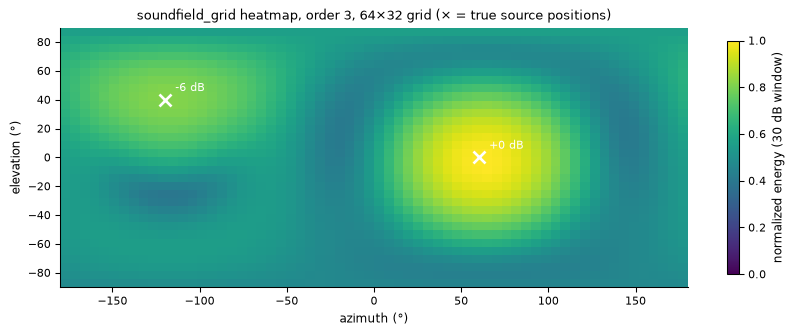

In [2]:
fs, n, order = 48000, 48000, 3
rng = np.random.default_rng(7)
srcs = [  # (azimuth°, elevation°, level dB)
    (60.0, 0.0, 0.0),
    (-120.0, 40.0, -6.0),
]
hoa = np.zeros((at.channel_count(order), n), dtype=np.float32)
for az_d, el_d, lvl in srcs:
    sig = 10 ** (lvl / 20) * rng.standard_normal(n).astype(np.float32)
    Y = at.evaluate_sh(order, np.radians(az_d), np.radians(el_d))
    hoa += Y[:, None] * sig[None, :]

AZ_STEPS = 64
img, peak_db = at.soundfield_grid(hoa, order=order, az_steps=AZ_STEPS,
                                  sample_rate=fs, dynamic_range_db=30.0)

fig, ax = plt.subplots(figsize=(9, 3.6))
m = ax.imshow(img, origin="upper", cmap="viridis", vmin=0, vmax=1,
              extent=[-180, 180, -90, 90], aspect="auto")
for az_d, el_d, lvl in srcs:
    ax.plot(az_d, el_d, "x", color="w", ms=9, mew=2)
    ax.annotate(f"{lvl:+.0f} dB", (az_d + 6, el_d + 6), color="w", fontsize=8)
ax.set(xlabel="azimuth (°)", ylabel="elevation (°)", title="soundfield_grid heatmap, "
       f"order 3, {AZ_STEPS}×{AZ_STEPS // 2} grid (× = true source positions)")
ax.grid(False)
fig.colorbar(m, ax=ax, label="normalized energy (30 dB window)", shrink=0.9)
fig.tight_layout()


In [3]:
# VERIFY: the global peak sits on the louder source, the second source is a
# strong local maximum, and their level difference matches the -6 dB offset.
cell = 360.0 / AZ_STEPS                      # 5.625° per azimuth step

def cell_of(az_d, el_d):
    col = int(round((az_d + 180.0) / cell)) % AZ_STEPS
    row = int(round((90.0 - el_d) / cell)) % (AZ_STEPS // 2)
    return row, col

r0, c0 = np.unravel_index(np.argmax(img), img.shape)
az_peak = -180.0 + c0 * cell
el_peak = 90.0 - r0 * cell
print(f"global peak at ({az_peak:.1f}°, {el_peak:.1f}°); truth (60°, 0°); "
      f"absolute peak {peak_db:.1f} dB")
assert abs(az_peak - 60.0) <= cell and abs(el_peak - 0.0) <= cell

v_a = img[cell_of(60.0, 0.0)]
db_a = (v_a - 1.0) * 30.0                    # invert the normalization
assert db_a > -1.0, "the louder source must sit at the top of the window"

# Source B: the true position falls between cells, so locate it as the
# regional peak on its side of the sphere and check position + level.
cols_b = slice(0, int((-60.0 + 180.0) / cell))          # azimuth in [-180, -60)
r1, c1 = np.unravel_index(np.argmax(img[:, cols_b]), img[:, cols_b].shape)
az_b = -180.0 + c1 * cell
el_b = 90.0 - r1 * cell
v_b = img[r1, c1]
db_b = (v_b - 1.0) * 30.0
print(f"source A cell reads {db_a:.2f} dB; source B peak at ({az_b:.1f}°, {el_b:.1f}°) "
      f"reads {db_b:.2f} dB (truth: (-120°, 40°) at -6 dB)")
assert abs(az_b - (-120.0)) <= 1.5 * cell and abs(el_b - 40.0) <= 1.5 * cell, \
    "source B's regional peak must sit on the true direction"
assert -10.0 < db_b < -3.0, "the quieter source must read ≈ 6 dB down"
assert v_b > np.median(img) + 0.2, "the second source must stand out of the floor"
print("soundfield heatmap verified against ground truth")


global peak at (61.9°, 0.0°); truth (60°, 0°); absolute peak 12.0 dB
source A cell reads 0.00 dB; source B peak at (-118.1°, 45.0°) reads -5.57 dB (truth: (-120°, 40°) at -6 dB)
soundfield heatmap verified against ground truth


## 2. DOA tracking (`analysis::energy_vector`)

The energy vector is the smoothed active intensity $\vec I = W \cdot (X, Y,
Z)$ — a first-order broadband DOA estimate, cheap enough for meters. We move
a noise source along a known trajectory (azimuth −135° → 135° while rising
0° → 30°) and compare the estimate against the truth. The 10 ms one-pole
smoothing means the estimate trails slightly during motion; after the initial
settle it should track within a few degrees.


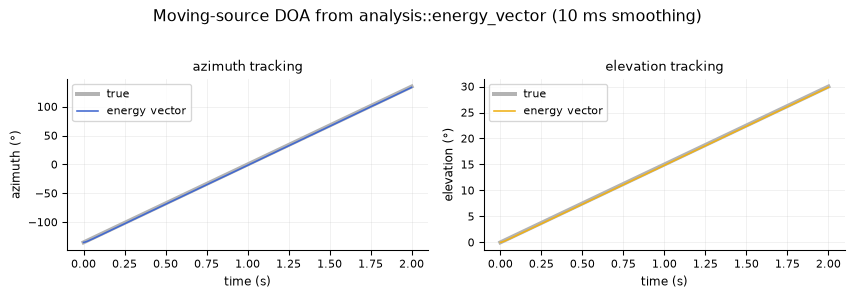

In [4]:
dur = 2.0
n = int(dur * fs)
block = 64                                    # direction updated per block, like a real app
az_true = np.radians(np.linspace(-135, 135, n)).astype(np.float32)
el_true = np.radians(np.linspace(0, 30, n)).astype(np.float32)

sig = rng.standard_normal(n).astype(np.float32)
hoa = np.zeros((at.channel_count(1), n), dtype=np.float32)
for s in range(0, n, block):
    e = min(s + block, n)
    Y = at.evaluate_sh(1, float(az_true[s]), float(el_true[s]))
    hoa[:, s:e] = Y[:, None] * sig[None, s:e]

v = at.energy_vector(hoa, order=1, sample_rate=fs, smoothing_s=0.01)
az_est = np.arctan2(v[1], v[0])
el_est = np.arctan2(v[2], np.hypot(v[0], v[1]))

tt = np.arange(n) / fs
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
axes[0].plot(tt, np.degrees(az_true), color="0.7", lw=3, label="true")
axes[0].plot(tt, np.degrees(az_est), color=PAL[0], lw=1.2, label="energy vector")
axes[0].set(xlabel="time (s)", ylabel="azimuth (°)", title="azimuth tracking")
axes[0].legend()
axes[1].plot(tt, np.degrees(el_true), color="0.7", lw=3, label="true")
axes[1].plot(tt, np.degrees(el_est), color=PAL[1], lw=1.2, label="energy vector")
axes[1].set(xlabel="time (s)", ylabel="elevation (°)", title="elevation tracking")
axes[1].legend()
fig.suptitle("Moving-source DOA from analysis::energy_vector (10 ms smoothing)", y=1.02)
fig.tight_layout()


In [5]:
# VERIFY: angular error after the 100 ms settle.
def angular_error_deg(az1, el1, az2, el2):
    cos_g = (np.sin(el1) * np.sin(el2)
             + np.cos(el1) * np.cos(el2) * np.cos(az1 - az2))
    return np.degrees(np.arccos(np.clip(cos_g, -1.0, 1.0)))

settle = int(0.1 * fs)
err = angular_error_deg(az_true[settle:], el_true[settle:],
                        az_est[settle:], el_est[settle:])
print(f"angular error: median {np.median(err):.2f}°, p95 {np.percentile(err, 95):.2f}°, "
      f"max {err.max():.2f}°")
assert np.median(err) < 3.0
assert np.percentile(err, 95) < 10.0
print("energy-vector DOA tracking verified")


angular error: median 1.39°, p95 1.48°, max 1.56°
energy-vector DOA tracking verified


## 3. Which order do I need?

Order buys **angular sharpness**. Two complementary measurements, both from
the compiled code:

- the max-rE **virtual beam** an order-$N$ system can form (its −6 dB width
  is the effective "pixel size" of the soundfield), and
- the mean **energy-vector magnitude** $|r_E|$ of real decoders (ALLRAD +
  max-rE) on real layouts — $|r_E| \to 1$ means tight, well-localized
  playback; Gerzon's criterion asks for $|r_E| \gtrsim 0.7$ at first order
  and modern practice treats ≥ 0.9 as "sharp".


−6 dB beamwidth by order: {1: '224°', 2: '145°', 3: '109°', 4: '88°', 5: '74°'}


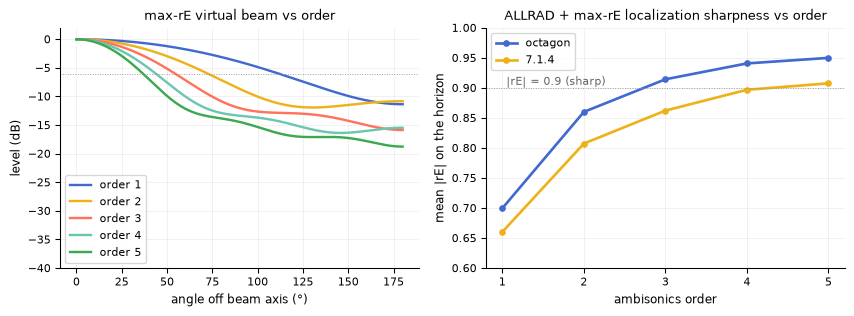

In [6]:
theta = np.linspace(0, np.pi, 1801)
Ymat = {N: at.sh_matrix(N, theta.astype(np.float32), np.zeros_like(theta, np.float32))
        for N in range(1, 6)}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
beamwidths = {}
for i, N in enumerate(range(1, 6)):
    w = at.max_re_weights(N)
    wa = np.concatenate([[w[nn]] * (2 * nn + 1) for nn in range(N + 1)])
    y0 = at.evaluate_sh(N, 0.0, 0.0)
    b = np.abs((Ymat[N] * (wa * y0)).sum(axis=1))
    b /= b.max()
    beamwidths[N] = 2 * np.degrees(theta[np.argmax(b < 0.5)])
    axes[0].plot(np.degrees(theta), 20 * np.log10(np.maximum(b, 1e-4)),
                 color=PAL[i], lw=1.8, label=f"order {N}")
axes[0].axhline(-6.02, color="0.6", lw=0.7, ls=":")
axes[0].set(xlabel="angle off beam axis (°)", ylabel="level (dB)", ylim=(-40, 2),
            title="max-rE virtual beam vs order")
axes[0].legend()

layouts = {"octagon": PAL[0], "7.1.4": PAL[1]}
orders = np.arange(1, 6)
az_h = np.linspace(-np.pi, np.pi, 721).astype(np.float32)
el_h = np.zeros_like(az_h)
re_by_layout = {}
for name, color in layouts.items():
    az_l, el_l = at.layout(name)
    u = np.stack([np.cos(az_l) * np.cos(el_l), np.sin(az_l) * np.cos(el_l), np.sin(el_l)])
    means = []
    for N in orders:
        D = at.decoder_matrix("allrad", int(N), az_l, el_l, use_max_re=True)
        G = D @ at.sh_matrix(int(N), az_h, el_h).T
        E = (G**2).sum(axis=0)
        rE = (u @ G**2) / E
        means.append(np.linalg.norm(rE, axis=0).mean())
    re_by_layout[name] = np.array(means)
    axes[1].plot(orders, means, color=color, lw=2, marker="o", ms=4, label=name)
axes[1].axhline(0.9, color="0.6", lw=0.7, ls=":")
axes[1].annotate("|rE| = 0.9 (sharp)", (1.05, 0.905), fontsize=8, color="0.4")
axes[1].set(xlabel="ambisonics order", ylabel="mean |rE| on the horizon",
            xticks=orders, ylim=(0.6, 1.0),
            title="ALLRAD + max-rE localization sharpness vs order")
axes[1].legend()
fig.tight_layout()

print("−6 dB beamwidth by order:",
      {N: f"{bw:.0f}°" for N, bw in beamwidths.items()})


In [7]:
# VERIFY: sharpness is monotone in order — the beam narrows and |rE| rises —
# and the absolute numbers sit where the literature puts them.
bw = np.array([beamwidths[N] for N in range(1, 6)])
assert np.all(np.diff(bw) < 0), "beamwidth must shrink monotonically with order"
assert 200 < bw[0] < 240 and 60 < bw[4] < 90, "order-1/order-5 beamwidths (≈224°, ≈74°)"

for name, m in re_by_layout.items():
    assert np.all(np.diff(m) > 0), f"|rE| must increase with order on {name}"
    assert m[0] > 0.6 and m[-1] > 0.9, f"order-5 playback on {name} must be sharp (|rE| > 0.9)"
print("order study verified: beamwidths", np.round(bw, 1),
      "; octagon |rE|", np.round(re_by_layout["octagon"], 3))


order study verified: beamwidths [223.6 145.2 109.   87.8  73.6] ; octagon |rE| [0.7   0.86  0.914 0.941 0.95 ]


## Summary

- `analysis::soundfield_grid` puts both test sources in the correct cells
  (within one 5.6° grid step) with the correct ~6 dB level offset.
- `analysis::energy_vector` tracks a moving source to a **median error
  < 3°** (p95 < 10°) with 10 ms smoothing.
- Order buys sharpness on a predictable curve: the max-rE beam narrows from
  ≈ 224° (order 1) to ≈ 74° (order 5), and real ALLRAD decodes cross the
  $|r_E| = 0.9$ "sharp" line around order 3–4 on the layouts tested.

Practical guidance from these numbers: order 1 is a meter/preview format,
order 3 (16 ch) is the sweet spot for real speaker rigs, order 5 (36 ch) is
worth it for binaural and dense arrays.
